In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# FASEROH: Teaching Neural Networks to Compute Taylor Series
## Notebook 1 — Data Generation, LSTM, and Transformer Training

**Author:** Vishal Lohiya | IIT Jodhpur | GSoC 2026 — ML4Sci

**Mentors:** Abdulhakim Alnuqaydan (U. of Kentucky), Harrison Prosper (FSU)

---

### What This Notebook Does

This notebook implements a **neural machine translation system** that converts mathematical functions into their Taylor series expansions — like translating English to French, but for math:

```
sin(x)      →  x - x³/6
exp(x)      →  1 + x + x²/2 + x³/6 + x⁴/24
cos(2x)     →  1 - 2x² + 2x⁴/3
```

We complete all three evaluation tasks:
- **Task 1:** Generate dataset with SymPy + build math-aware tokenizer
- **Task 2:** Train LSTM + Attention model
- **Task 3:** Train Transformer model

Then we compare both models, discover the **exposure bias problem**, and explain why the LSTM outperforms the Transformer despite having higher validation loss.

**Notebook 2** (`02_Beam_Search_and_Experiments.ipynb`) continues with beam search decoding and teacher forcing decay experiments.

---
## 0. Setup & Dependencies

In [1]:
# Install dependencies (uncomment if needed)
# !pip install torch sympy numpy pandas matplotlib scikit-learn

import re, time, random, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import sympy as sp
from sympy import (Symbol, series, sin, cos, exp, log, tan, sqrt,
                   atan, asin, acos, sinh, cosh, tanh, Rational,
                   expand, zoo, nan, oo, I)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU (training will be slower)")

x = Symbol('x')
print(f"\nDevice: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"SymPy: {sp.__version__}")
print("\n✅ Setup complete!")

GPU: Tesla T4
VRAM: 15.6 GB

Device: cuda
PyTorch: 2.10.0+cu128
SymPy: 1.14.0

✅ Setup complete!


---
## 1. Task 1 — Data Generation with SymPy

### 1.1 Generating Our Own Dataset

We generate mathematical functions across **8 difficulty levels** — from simple `sin(x)` to complex nested compositions like `sin(cos(exp(x)))`. For each function, we compute its Taylor expansion to 4th order using SymPy's `series()` function.

| Level | Type | Example | Why It's Harder |
|:-----:|------|---------|----------------|
| 1 | Basic | `sin(x)`, `exp(x)` | Simple — one function |
| 2 | Scaled | `sin(2x)`, `exp(-x)` | Coefficients change the expansion |
| 3 | Polynomials | `3x³ - 2x + 1` | Identity mapping (already a Taylor expansion) |
| 4 | Compositions | `sin(cos(x))` | Must expand outer AND inner function |
| 5 | Products | `x·exp(x)` | Multiply two expansions together |
| 6 | Sums | `sin(x) + 2cos(x)` | Combine multiple expansions |
| 7 | Powers | `√(1+x)` | Binomial/generalized expansion |
| 8 | Deep nesting | `sin(cos(exp(x)))` | 3 levels of composition |

In [5]:
!find /content/drive/MyDrive -name "our_19k_data.csv" 2>/dev/null

/content/drive/MyDrive/Colab Notebooks/Gsoc 2026/ML4sci/our_19k_data.csv


In [4]:
import os

# Load pre-generated data (skip 5-min SymPy generation)
USE_PREGENERATED = True

if USE_PREGENERATED:
    csv_path = '/content/drive/MyDrive/Colab Notebooks/Gsoc 2026/ML4sci/our_19k_data.csv'
    if os.path.exists(csv_path):
        our_df = pd.read_csv(csv_path)
        print(f"✅ Loaded pre-generated SymPy data: {len(our_df)} pairs")
        print(f"\nSample pairs:")
        for _, row in our_df.sample(5, random_state=42).iterrows():
            print(f"  {row['function']:40s} → {row['taylor_expansion'][:60]}")
    else:
        print(f"⚠️ CSV not found at {csv_path}")

✅ Loaded pre-generated SymPy data: 18812 pairs

Sample pairs:
  2*sin(x)*sin(2*x)*cos(2*x)               → -34*x**4/3 + 4*x**2
  -3*x**2 - 2*log(x + 1) + cos(x)**2/3     → 11*x**4/18 - 2*x**3/3 - 7*x**2/3 - 2*x + 1/3
  -2*x**2 + 2*sqrt(x + 1) + 3*sin(x) + tan(x)/2 → -5*x**4/64 - 5*x**3/24 - 9*x**2/4 + 9*x/2 + 2
  3*x - 2*exp(x) + 2*cos(x)**2             → 7*x**4/12 - x**3/3 - 3*x**2 + x
  -9*x - 4                                 → -9*x - 4


In [ ]:
# if you have to generate 19K of your own then run the cell below but i got the csv file for 19k data sets generated already

In [ ]:
print("="*60)
print("TASK 1: GENERATING DATASET WITH SYMPY")
print("="*60)

t0 = time.time()
dataset = []
seen_funcs = set()
seen_taylors = set()
errors = 0

def try_add(func_expr):
    """Try to compute Taylor expansion and add to dataset."""
    global errors
    try:
        func_str = str(func_expr)
        if func_str in seen_funcs or len(func_str) > 150:
            return
        taylor = series(func_expr, x, 0, n=5).removeO()
        taylor = expand(taylor)
        taylor_str = str(taylor)
        if taylor == 0 or len(taylor_str) > 200:
            return
        if taylor.has(zoo, nan, oo, I):
            return
        if taylor_str in seen_taylors:
            return
        seen_funcs.add(func_str)
        seen_taylors.add(taylor_str)
        dataset.append({'function': func_str, 'taylor_expansion': taylor_str})
    except:
        errors += 1

# Level 1: Basic functions
print("Level 1: Basic functions...")
for f in [sin(x), cos(x), exp(x), log(1+x), tan(x), sinh(x), cosh(x),
          tanh(x), asin(x), atan(x), exp(-x), 1/(1-x), 1/(1+x), sqrt(1+x)]:
    try_add(f)
print(f"  {len(dataset)} pairs")

# Level 2: Scaled functions
print("Level 2: Scaled functions...")
for func in [sin, cos, exp, lambda u: log(1+u), tan, sinh, cosh, tanh, atan]:
    for a in [2, 3, 4, 5, -1, -2, -3, Rational(1,2), Rational(1,3),
             Rational(1,4), Rational(2,3), Rational(3,2)]:
        try_add(func(a*x))
        try_add(func(a*x**2))
        try_add(a*func(x))
        try_add(a*func(2*x))
print(f"  {len(dataset)} pairs")

# Level 3: Random polynomials
print("Level 3: Random polynomials...")
for _ in range(3000):
    deg = random.randint(1, 4)
    coeffs = [random.randint(-9, 9) for _ in range(deg + 1)]
    if all(c == 0 for c in coeffs):
        coeffs[-1] = 1
    try_add(sum(c * x**i for i, c in enumerate(coeffs)))
print(f"  {len(dataset)} pairs")

# Level 4: Compositions f(g(x))
print("Level 4: Compositions...")
outers = [sin, cos, exp, lambda u: log(1+u), lambda u: 1/(1+u),
          lambda u: sqrt(1+u), lambda u: (1+u)**2]
inners = [x, 2*x, -x, x/2, x/3, 3*x, x**2, x**2/2, -x**2,
          sin(x), cos(x), exp(x)-1, x+x**2]
for _ in range(10000):
    try_add(random.choice(outers)(random.choice(inners)))
print(f"  {len(dataset)} pairs")

# Level 5: Products
print("Level 5: Products...")
factors = [sin(x), cos(x), exp(x), exp(-x), x, x**2, x**3, x**4,
           log(1+x), 1/(1+x), sqrt(1+x), (1+x)**2, sin(2*x),
           cos(2*x), exp(x/2), 1/(1+x**2)]
for _ in range(15000):
    terms = random.sample(factors, min(random.choice([2, 2, 3]), len(factors)))
    c = random.choice([1, -1, 2, -2, 3, Rational(1,2), Rational(1,3)])
    f = c
    for t in terms:
        f = f * t
    try_add(f)
print(f"  {len(dataset)} pairs")

# Level 6: Sums
print("Level 6: Sums...")
sum_bases = [sin(x), cos(x), exp(x), exp(-x), log(1+x), x, x**2, x**3,
             1/(1+x), sqrt(1+x), tan(x), sinh(x), cosh(x), tanh(x),
             sin(2*x), cos(2*x), sin(x)**2, cos(x)**2, x*sin(x), x*cos(x)]
for _ in range(15000):
    terms = random.sample(sum_bases, min(random.choice([2, 3, 3, 4]), len(sum_bases)))
    coeffs = [random.choice([1,-1,2,-2,3,-3,Rational(1,2),Rational(1,3)]) for _ in terms]
    try_add(sum(c*t for c, t in zip(coeffs, terms)))
print(f"  {len(dataset)} pairs")

# Level 7: Power functions
print("Level 7: Powers...")
for _ in range(5000):
    n = random.choice([2, 3, -1, -2, Rational(1,2), Rational(3,2)])
    base = random.choice([1+x, 1-x, 1+2*x, 1+x/2, 1+x**2, 1-x**2, 1+sin(x), exp(x)])
    try_add(base**n)
print(f"  {len(dataset)} pairs")

# Level 8: Deep compositions
print("Level 8: Deep compositions...")
for _ in range(8000):
    f = x
    for _ in range(random.choice([2, 3])):
        op = random.choice([
            lambda u: sin(u), lambda u: cos(u), lambda u: u**2,
            lambda u: 2*u, lambda u: u/2, lambda u: -u,
            lambda u: u + 1, lambda u: exp(u)
        ])
        f = op(f)
    try_add(f)

elapsed = time.time() - t0
print(f"\n{'='*60}")
print(f"Generated {len(dataset)} unique pairs in {elapsed:.0f}s")
print(f"Errors skipped: {errors}")
print(f"{'='*60}")

our_df = pd.DataFrame(dataset)
print(f"\nSample pairs:")
for _, row in our_df.sample(5, random_state=42).iterrows():
    print(f"  {row['function']:40s} → {row['taylor_expansion'][:60]}")

### 1.2 Loading the Mentor's 60K Dataset

We also use [Harrison Prosper's dataset](https://github.com/hbprosper/symbolic-ai) which contains 57,006 unique pairs. This data is **harder** than ours — it includes functions with numerical constants like `cos(6)`, `exp(5)`, and `sinh(9)` in the Taylor expansions.

We combine both datasets for training, giving us the most diverse possible training set.

In [5]:
import urllib.request

print("Downloading Prosper's 60K dataset from GitHub...")
url = "https://raw.githubusercontent.com/hbprosper/symbolic-ai/main/data/seq2seq_data_60000.txt"
urllib.request.urlretrieve(url, "prosper_60k.txt")

prosper_pairs = []
for line in open("prosper_60k.txt"):
    parts = line.strip().split('\t')
    if len(parts) == 2:
        prosper_pairs.append({'function': parts[0], 'taylor_expansion': parts[1]})

prosper_df = pd.DataFrame(prosper_pairs).drop_duplicates(subset=['function'])
print(f"Prosper's dataset: {len(prosper_df)} unique pairs")

# Combine both datasets
combined_df = pd.concat([our_df, prosper_df], ignore_index=True)
combined_df = combined_df.drop_duplicates(subset=['function']).reset_index(drop=True)
print(f"Our dataset:       {len(our_df)} pairs")
print(f"Combined dataset:  {len(combined_df)} pairs")

# Save our dataset for reproducibility
our_df.to_csv('our_sympy_data.csv', index=False)
print(f"\nSaved our SymPy data to: our_sympy_data.csv")

Prosper's dataset: 57006 unique pairs
Our dataset:       18812 pairs
Combined dataset:  75772 pairs

Saved our SymPy data to: our_sympy_data.csv


### 1.3 The Tokenization Breakthrough

This is the **most important design decision** in the project.

Prior work used **character-level** tokenization:
```
sin(2*x) → ['s', 'i', 'n', '(', '2', '*', 'x', ')']    # model must learn s+i+n = sine
```

Our **math-aware** tokenizer treats function names as single tokens:
```
sin(2*x) → ['sin', '(', '2', '*', 'x', ')']             # 'sin' is one meaningful token
```

Multi-digit numbers are split into individual digits to keep the vocabulary small:
```
1024 → ['1', '0', '2', '4']    # only need 10 digit tokens instead of hundreds
```

**Result: 34 tokens total.** This led to a **97x reduction in training time** compared to the character-level baseline.

In [6]:
class MathTokenizer:
    """Math-aware tokenizer that treats function names as atomic tokens."""

    PAD_TOKEN = '<PAD>'   # Padding (fills sequences to equal length)
    SOS_TOKEN = '<SOS>'   # Start of sequence (tells decoder to begin)
    EOS_TOKEN = '<EOS>'   # End of sequence (tells decoder to stop)
    UNK_TOKEN = '<UNK>'   # Unknown token (fallback)

    def __init__(self):
        self.token2idx = {}
        self.idx2token = {}
        self.vocab_size = 0
        # Add special tokens
        for i, t in enumerate([self.PAD_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN, self.UNK_TOKEN]):
            self.token2idx[t] = i
            self.idx2token[i] = t
        self.vocab_size = 4

    def tokenize(self, expr_str):
        """Convert math expression string to list of tokens."""
        expr_str = expr_str.replace(" ", "")
        # Match function names first, then operators, then digits, then variables
        pattern = r'(sin|cos|tan|exp|log|sqrt|sinh|cosh|tanh|asin|acos|atan|\*\*|\d+|\+|\-|\*|/|\(|\)|x)'
        raw_tokens = re.findall(pattern, expr_str)
        # Split multi-digit numbers into individual digits
        tokens = []
        for token in raw_tokens:
            if token.isdigit() and len(token) > 1:
                for digit in token:
                    tokens.append(digit)
            else:
                tokens.append(token)
        return tokens

    def build_vocab(self, expressions=None):
        """Build vocabulary from known math tokens."""
        math_tokens = [
            '0','1','2','3','4','5','6','7','8','9',  # digits
            '+','-','*','/','**',                       # operators
            '(',')',                                     # parentheses
            'x',                                        # variable
            'sin','cos','tan','exp','log','sqrt',       # functions
            'sinh','cosh','tanh','asin','acos','atan'   # more functions
        ]
        for t in math_tokens:
            if t not in self.token2idx:
                self.token2idx[t] = self.vocab_size
                self.idx2token[self.vocab_size] = t
                self.vocab_size += 1
        # Check for unknown tokens in data
        if expressions:
            for expr in expressions:
                for t in self.tokenize(expr):
                    if t not in self.token2idx:
                        self.token2idx[t] = self.vocab_size
                        self.idx2token[self.vocab_size] = t
                        self.vocab_size += 1
        print(f"Vocabulary: {self.vocab_size} tokens")
        return self

    def encode(self, expr_str, add_sos=False, add_eos=False):
        """Convert expression string to list of token indices."""
        ids = []
        if add_sos:
            ids.append(self.token2idx[self.SOS_TOKEN])
        for t in self.tokenize(expr_str):
            ids.append(self.token2idx.get(t, self.token2idx[self.UNK_TOKEN]))
        if add_eos:
            ids.append(self.token2idx[self.EOS_TOKEN])
        return ids

    def decode(self, ids):
        """Convert token indices back to expression string."""
        tokens = [self.idx2token.get(i, self.UNK_TOKEN) for i in ids
                  if self.idx2token.get(i, '') not in [self.PAD_TOKEN, self.SOS_TOKEN, self.EOS_TOKEN]]
        result = ''
        i = 0
        while i < len(tokens):
            t = tokens[i]
            if t.isdigit():
                num = t
                while i + 1 < len(tokens) and tokens[i+1].isdigit():
                    i += 1
                    num += tokens[i]
                result += num
            elif t in ['+', '-']:
                result += ' ' + t + ' '
            else:
                result += t
            i += 1
        return result.strip()

    def pad_sequence(self, ids, max_len):
        """Pad or truncate to max_len."""
        if len(ids) >= max_len:
            return ids[:max_len]
        return ids + [self.token2idx[self.PAD_TOKEN]] * (max_len - len(ids))


# Build tokenizer on combined data
tokenizer = MathTokenizer()
all_exprs = combined_df['function'].tolist() + combined_df['taylor_expansion'].tolist()
tokenizer.build_vocab(all_exprs)
VOCAB_SIZE = tokenizer.vocab_size

# Demonstrate tokenization
print("\n--- Tokenization Examples ---")
examples = ["exp(x)", "sin(2*x)", "x**2/24", "1 + x + x**2/2"]
for expr in examples:
    tokens = tokenizer.tokenize(expr)
    encoded = tokenizer.encode(expr)
    print(f"  {expr:25s} → tokens: {tokens}")
    print(f"  {'':25s} → ids:    {encoded}")

Vocabulary: 34 tokens

--- Tokenization Examples ---
  exp(x)                    → tokens: ['exp', '(', 'x', ')']
                            → ids:    [25, 19, 21, 20]
  sin(2*x)                  → tokens: ['sin', '(', '2', '*', 'x', ')']
                            → ids:    [22, 19, 6, 16, 21, 20]
  x**2/24                   → tokens: ['x', '**', '2', '/', '2', '4']
                            → ids:    [21, 18, 6, 17, 6, 8]
  1 + x + x**2/2            → tokens: ['1', '+', 'x', '+', 'x', '**', '2', '/', '2']
                            → ids:    [5, 14, 21, 14, 21, 18, 6, 17, 6]


### 1.4 Preparing the Data for Training

In [7]:
# Compute sequence lengths for padding
func_lens = [len(tokenizer.tokenize(f)) for f in combined_df['function']]
taylor_lens = [len(tokenizer.tokenize(t)) for t in combined_df['taylor_expansion']]

MAX_INPUT_LEN = int(np.percentile(func_lens, 95)) + 5
MAX_OUTPUT_LEN = min(int(np.percentile(taylor_lens, 95)) + 5, 120)

# Filter out sequences that are too long
df = combined_df[
    (combined_df['function'].apply(lambda f: len(tokenizer.tokenize(f)) <= MAX_INPUT_LEN - 3)) &
    (combined_df['taylor_expansion'].apply(lambda t: len(tokenizer.tokenize(t)) <= MAX_OUTPUT_LEN - 3))
].reset_index(drop=True)

print(f"After filtering long sequences: {len(df)} pairs")
print(f"Max input length:  {MAX_INPUT_LEN} tokens")
print(f"Max output length: {MAX_OUTPUT_LEN} tokens")
print(f"Vocabulary size:   {VOCAB_SIZE} tokens")

# Train / Validation / Test split
train_df, temp_df = train_test_split(df, test_size=0.15, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.33, random_state=SEED)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# PyTorch Dataset
class TaylorDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_in, max_out):
        self.data = dataframe.reset_index(drop=True)
        self.tok = tokenizer
        self.max_in = max_in
        self.max_out = max_out

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        src = self.tok.pad_sequence(self.tok.encode(row['function']), self.max_in)
        tgt = self.tok.pad_sequence(
            self.tok.encode(row['taylor_expansion'], add_sos=True, add_eos=True),
            self.max_out
        )
        return {
            'src': torch.tensor(src, dtype=torch.long),
            'tgt': torch.tensor(tgt, dtype=torch.long)
        }

# Create data loaders
BATCH_SIZE = 128

train_loader = DataLoader(
    TaylorDataset(train_df, tokenizer, MAX_INPUT_LEN, MAX_OUTPUT_LEN),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    TaylorDataset(val_df, tokenizer, MAX_INPUT_LEN, MAX_OUTPUT_LEN),
    batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    TaylorDataset(test_df, tokenizer, MAX_INPUT_LEN, MAX_OUTPUT_LEN),
    batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")
print("\n✅ Task 1 complete! Data ready for training.")

After filtering long sequences: 63613 pairs
Max input length:  57 tokens
Max output length: 120 tokens
Vocabulary size:   34 tokens

Train: 54071 | Val: 6393 | Test: 3149
Batches — Train: 423 | Val: 50 | Test: 25

✅ Task 1 complete! Data ready for training.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


---
## 2. Task 2 — LSTM + Attention

### Architecture

Our LSTM model has three components:

1. **Bidirectional Encoder** — reads the input function from both directions, creating rich context vectors
2. **Bahdanau Attention** — at each decoding step, decides which parts of the input to focus on
3. **Decoder with Teacher Forcing Decay** — generates the Taylor expansion token by token, gradually learning to use its own predictions instead of correct tokens

The teacher forcing decay schedule is critical — it's why this LSTM outperforms the Transformer on test accuracy.

In [8]:
# ============================================================
# LSTM Encoder-Decoder with Bahdanau Attention
# ============================================================

class LSTMEncoder(nn.Module):
    """Bidirectional LSTM encoder."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers,
                           batch_first=True, dropout=dropout if n_layers > 1 else 0,
                           bidirectional=True)
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        # Combine bidirectional hidden states
        hidden = torch.tanh(self.fc_hidden(torch.cat([hidden[-2], hidden[-1]], dim=1))).unsqueeze(0)
        cell = torch.tanh(self.fc_cell(torch.cat([cell[-2], cell[-1]], dim=1))).unsqueeze(0)
        return outputs, hidden, cell


class BahdanauAttention(nn.Module):
    """Additive attention mechanism."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        hidden_expanded = hidden.squeeze(0).unsqueeze(1).repeat(1, encoder_outputs.shape[1], 1)
        energy = torch.tanh(self.attn(torch.cat([hidden_expanded, encoder_outputs], dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


class LSTMDecoder(nn.Module):
    """LSTM decoder with attention."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        self.lstm = nn.LSTM(embed_dim + hidden_dim * 2, hidden_dim, 1, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 3 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(token))
        attn_weights = self.attention(hidden, encoder_outputs).unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)
        lstm_input = torch.cat([embedded, context], dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(torch.cat([output, context, embedded], dim=2))
        return prediction.squeeze(1), hidden, cell


class Seq2SeqLSTM(nn.Module):
    """Complete LSTM seq2seq model with attention and teacher forcing."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(vocab_size, embed_dim, hidden_dim, n_layers, dropout)
        self.decoder = LSTMDecoder(vocab_size, embed_dim, hidden_dim, n_layers, dropout)
        self.vocab_size = vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape[0], tgt.shape[1]
        encoder_outputs, hidden, cell = self.encoder(src)

        outputs = torch.zeros(batch_size, tgt_len, self.vocab_size).to(src.device)
        decoder_input = tgt[:, 0:1]  # Start with SOS token

        for t in range(1, tgt_len):
            prediction, hidden, cell = self.decoder(decoder_input, hidden, cell, encoder_outputs)
            outputs[:, t] = prediction
            # Teacher forcing: use correct token or model's own prediction
            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t:t+1]        # correct token
            else:
                decoder_input = prediction.argmax(dim=1, keepdim=True)  # own prediction

        return outputs


# Initialize model
EMBED_DIM = 128
HIDDEN_DIM = 256
N_LAYERS = 2
DROPOUT = 0.3

lstm_model = Seq2SeqLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(device)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"LSTM Model Parameters: {total_params:,}")

LSTM Model Parameters: 3,786,018


### 2.1 Training the LSTM

**Teacher forcing schedule:** Starts at 1.0 (always use correct previous token) and linearly decays to 0.1 (almost always use model's own predictions). This is crucial — by training end, the model has practiced recovering from its own mistakes, which is exactly what happens during real inference.

In [9]:
print("="*60)
print("TRAINING LSTM + ATTENTION")
print("="*60)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)  # ignore PAD tokens
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

LSTM_EPOCHS = 40
lstm_history = {'train': [], 'val': []}
best_lstm_val = float('inf')

for epoch in range(LSTM_EPOCHS):
    # Teacher forcing decay: 1.0 → 0.1
    tf_ratio = max(0.1, 1.0 - epoch * 0.025)

    # --- Train ---
    lstm_model.train()
    train_loss = 0
    for batch in train_loader:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)
        optimizer.zero_grad()
        output = lstm_model(src, tgt, teacher_forcing_ratio=tf_ratio)
        output = output[:, 1:].contiguous().view(-1, VOCAB_SIZE)
        target = tgt[:, 1:].contiguous().view(-1)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validate ---
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            output = lstm_model(src, tgt, teacher_forcing_ratio=0)
            output = output[:, 1:].contiguous().view(-1, VOCAB_SIZE)
            target = tgt[:, 1:].contiguous().view(-1)
            val_loss += criterion(output, target).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    lstm_history['train'].append(train_loss)
    lstm_history['val'].append(val_loss)

    # Save best model
    star = ''
    if val_loss < best_lstm_val:
        best_lstm_val = val_loss
        torch.save(lstm_model.state_dict(), 'best_lstm.pth')
        star = ' ★ saved'

    lr = optimizer.param_groups[0]['lr']
    print(f"Ep {epoch+1:2d}/{LSTM_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.6f} | TF: {tf_ratio:.2f}{star}")

print(f"\nBest LSTM validation loss: {best_lstm_val:.4f}")

TRAINING LSTM + ATTENTION


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ep  1/40 | Train: 1.0416 | Val: 6.3926 | LR: 0.001000 | TF: 1.00 ★ saved
Ep  2/40 | Train: 0.6055 | Val: 5.7843 | LR: 0.001000 | TF: 0.97 ★ saved
Ep  3/40 | Train: 0.4931 | Val: 5.3333 | LR: 0.001000 | TF: 0.95 ★ saved
Ep  4/40 | Train: 0.4342 | Val: 5.0077 | LR: 0.001000 | TF: 0.93 ★ saved
Ep  5/40 | Train: 0.4000 | Val: 4.6515 | LR: 0.001000 | TF: 0.90 ★ saved
Ep  6/40 | Train: 0.3758 | Val: 4.3337 | LR: 0.001000 | TF: 0.88 ★ saved
Ep  7/40 | Train: 0.3600 | Val: 4.1223 | LR: 0.001000 | TF: 0.85 ★ saved
Ep  8/40 | Train: 0.3485 | Val: 3.9404 | LR: 0.001000 | TF: 0.82 ★ saved
Ep  9/40 | Train: 0.3384 | Val: 3.7959 | LR: 0.001000 | TF: 0.80 ★ saved
Ep 10/40 | Train: 0.3345 | Val: 3.6624 | LR: 0.001000 | TF: 0.78 ★ saved
Ep 11/40 | Train: 0.3295 | Val: 3.5791 | LR: 0.001000 | TF: 0.75 ★ saved
Ep 12/40 | Train: 0.3292 | Val: 3.4493 | LR: 0.001000 | TF: 0.72 ★ saved
Ep 13/40 | Train: 0.3261 | Val: 3.3018 | LR: 0.001000 | TF: 0.70 ★ saved
Ep 14/40 | Train: 0.3326 | Val: 3.1924 | LR: 0.0010

In [13]:
import shutil
# Find the correct path
!find /content/drive/MyDrive -name "our_19k_data.csv" 2>/dev/null

/content/drive/MyDrive/Colab Notebooks/Gsoc 2026/ML4sci/our_19k_data.csv


In [14]:
import shutil, os

save_dir = '/content/drive/MyDrive/Colab Notebooks/Gsoc 2026/ML4sci/'

shutil.copy('best_lstm.pth', save_dir + 'best_lstm.pth')
print("✅ LSTM saved to Drive!")

shutil.copy('best_transformer.pth', save_dir + 'best_transformer.pth')
print("✅ Transformer saved to Drive!")

✅ LSTM saved to Drive!
✅ Transformer saved to Drive!


---
## 3. Task 3 — Transformer

### Architecture

The Transformer uses **self-attention** instead of recurrence. Key advantage: it processes all positions in parallel (much faster to train). We use:
- d_model = 256, 8 attention heads, 4 encoder/decoder layers
- Warmup + cosine annealing learning rate schedule
- Standard teacher forcing (TF = 1.0 throughout)

**Important:** Unlike the LSTM, the Transformer trains with constant full teacher forcing. As we'll see, this creates a train-test mismatch called **exposure bias**.

In [11]:
# ============================================================
# Transformer Encoder-Decoder
# ============================================================

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (from 'Attention Is All You Need')."""
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class Seq2SeqTransformer(nn.Module):
    """Standard Transformer encoder-decoder."""
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_ff, dropout):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, 500, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def make_tgt_mask(self, size):
        """Causal mask: prevents decoder from looking at future tokens."""
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def forward(self, src, tgt):
        tgt_mask = self.make_tgt_mask(tgt.shape[1])
        src_padding_mask = (src == 0)
        tgt_padding_mask = (tgt == 0)

        src_emb = self.positional_encoding(self.dropout(self.src_embedding(src) * np.sqrt(self.d_model)))
        tgt_emb = self.positional_encoding(self.dropout(self.tgt_embedding(tgt) * np.sqrt(self.d_model)))

        output = self.transformer(
            src_emb, tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask
        )
        return self.fc_out(output)


# Initialize Transformer
D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 4
DIM_FF = 1024

transformer_model = Seq2SeqTransformer(VOCAB_SIZE, D_MODEL, NHEAD, NUM_LAYERS, DIM_FF, DROPOUT).to(device)

total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Transformer Parameters: {total_params:,}")

Transformer Parameters: 7,399,970


In [12]:
print("="*60)
print("TRAINING TRANSFORMER")
print("="*60)

TRANSFORMER_EPOCHS = 50

# Warmup + Cosine Annealing LR
opt_t = torch.optim.Adam(transformer_model.parameters(), lr=5e-4, betas=(0.9, 0.98), eps=1e-9)
crit_t = nn.CrossEntropyLoss(ignore_index=0)

warmup_steps = len(train_loader) * 3  # 3 epochs warmup
total_steps = len(train_loader) * TRANSFORMER_EPOCHS
step = 0

def lr_lambda(s):
    if s < warmup_steps:
        return s / warmup_steps  # linear warmup
    progress = (s - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay

sched_t = torch.optim.lr_scheduler.LambdaLR(opt_t, lr_lambda)

transformer_history = {'train': [], 'val': []}
best_transformer_val = float('inf')

for epoch in range(TRANSFORMER_EPOCHS):
    transformer_model.train()
    train_loss = 0
    for batch in train_loader:
        src = batch['src'].to(device)
        tgt = batch['tgt'].to(device)
        opt_t.zero_grad()
        output = transformer_model(src, tgt[:, :-1])  # teacher forcing
        output = output.contiguous().view(-1, VOCAB_SIZE)
        target = tgt[:, 1:].contiguous().view(-1)
        loss = crit_t(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        opt_t.step()
        sched_t.step()
        train_loss += loss.item()
        step += 1
    train_loss /= len(train_loader)

    transformer_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            output = transformer_model(src, tgt[:, :-1])
            output = output.contiguous().view(-1, VOCAB_SIZE)
            target = tgt[:, 1:].contiguous().view(-1)
            val_loss += crit_t(output, target).item()
    val_loss /= len(val_loader)

    transformer_history['train'].append(train_loss)
    transformer_history['val'].append(val_loss)

    star = ''
    if val_loss < best_transformer_val:
        best_transformer_val = val_loss
        torch.save(transformer_model.state_dict(), 'best_transformer.pth')
        star = ' ★ saved'

    lr = opt_t.param_groups[0]['lr']
    print(f"Ep {epoch+1:2d}/{TRANSFORMER_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr:.6f}{star}")

print(f"\nBest Transformer validation loss: {best_transformer_val:.4f}")

TRAINING TRANSFORMER


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Ep  1/50 | Train: 2.2212 | Val: 1.4786 | LR: 0.000167 ★ saved
Ep  2/50 | Train: 1.3736 | Val: 1.1570 | LR: 0.000333 ★ saved
Ep  3/50 | Train: 1.1554 | Val: 0.9822 | LR: 0.000500 ★ saved
Ep  4/50 | Train: 1.0204 | Val: 0.8890 | LR: 0.000499 ★ saved
Ep  5/50 | Train: 0.9430 | Val: 0.8275 | LR: 0.000498 ★ saved
Ep  6/50 | Train: 0.8901 | Val: 0.7651 | LR: 0.000495 ★ saved
Ep  7/50 | Train: 0.8519 | Val: 0.7369 | LR: 0.000491 ★ saved
Ep  8/50 | Train: 0.8245 | Val: 0.7229 | LR: 0.000486 ★ saved
Ep  9/50 | Train: 0.8031 | Val: 0.6982 | LR: 0.000480 ★ saved
Ep 10/50 | Train: 0.7846 | Val: 0.6892 | LR: 0.000473 ★ saved
Ep 11/50 | Train: 0.7693 | Val: 0.6791 | LR: 0.000465 ★ saved
Ep 12/50 | Train: 0.7566 | Val: 0.6657 | LR: 0.000456 ★ saved
Ep 13/50 | Train: 0.7431 | Val: 0.6704 | LR: 0.000446
Ep 14/50 | Train: 0.7327 | Val: 0.6577 | LR: 0.000435 ★ saved
Ep 15/50 | Train: 0.7221 | Val: 0.6584 | LR: 0.000424
Ep 16/50 | Train: 0.7142 | Val: 0.6523 | LR: 0.000411 ★ saved
Ep 17/50 | Train: 0.7060

---
## 4. Evaluation — Greedy Decoding

Now we evaluate both models on the held-out test set using **greedy decoding** — at each step, pick the single most probable token.

### Metrics Explained

- **Exact Match:** Is the predicted Taylor expansion character-for-character identical to the correct answer? 25% exact match = 1 in 4 predictions is perfectly correct.
- **Token Accuracy:** What fraction of individual tokens are correct? Measures partial correctness.
- **BLEU-1:** Token overlap between prediction and ground truth. 93% BLEU = even "wrong" predictions share 93% of tokens with the correct answer — usually just one or two coefficients are off.

In [16]:
# ============================================================
# Greedy Decoding Functions
# ============================================================

def greedy_decode_lstm(model, src, tokenizer, max_len):
    """Generate Taylor expansion token by token (LSTM)."""
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)
        encoder_outputs, hidden, cell = model.encoder(src)
        decoder_input = torch.tensor([[tokenizer.token2idx[tokenizer.SOS_TOKEN]]]).to(device)
        output_tokens = []
        for _ in range(max_len):
            prediction, hidden, cell = model.decoder(decoder_input, hidden, cell, encoder_outputs)
            next_token = prediction.argmax(dim=1).item()
            if next_token == tokenizer.token2idx[tokenizer.EOS_TOKEN]:
                break
            output_tokens.append(next_token)
            decoder_input = torch.tensor([[next_token]]).to(device)
    return output_tokens


def greedy_decode_transformer(model, src, tokenizer, max_len):
    """Generate Taylor expansion token by token (Transformer)."""
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)
        sos = tokenizer.token2idx[tokenizer.SOS_TOKEN]
        eos = tokenizer.token2idx[tokenizer.EOS_TOKEN]
        tgt_ids = [sos]
        for _ in range(max_len):
            tgt_tensor = torch.tensor([tgt_ids]).to(device)
            output = model(src, tgt_tensor)
            next_token = output[0, -1].argmax().item()
            if next_token == eos:
                break
            tgt_ids.append(next_token)
    return tgt_ids[1:]  # remove SOS


def evaluate_model(model, decode_fn, name, test_df, tokenizer, max_in, max_out):
    """Evaluate a model on the test set with greedy decoding."""
    print(f"\n--- Evaluating: {name} ---")

    exact_matches = 0
    token_correct = 0
    token_total = 0
    bleu_scores = []
    results = []

    for idx in range(len(test_df)):
        row = test_df.iloc[idx]
        src = tokenizer.pad_sequence(tokenizer.encode(row['function']), max_in)
        src_tensor = torch.tensor(src, dtype=torch.long)
        true_str = row['taylor_expansion']
        true_idx = tokenizer.encode(true_str)

        # Predict
        pred_idx = decode_fn(model, src_tensor, tokenizer, max_out)
        pred_str = tokenizer.decode(pred_idx)

        # Exact match
        is_exact = (pred_str.replace(' ', '') == true_str.replace(' ', ''))
        if is_exact:
            exact_matches += 1

        # Token accuracy
        min_len = min(len(pred_idx), len(true_idx))
        token_correct += sum(1 for i in range(min_len) if pred_idx[i] == true_idx[i])
        token_total += max(len(pred_idx), len(true_idx))

        # BLEU-1
        pred_tokens = tokenizer.tokenize(pred_str) if pred_str else []
        true_tokens = tokenizer.tokenize(true_str)
        if pred_tokens:
            pred_counter = Counter(pred_tokens)
            true_counter = Counter(true_tokens)
            overlap = sum(min(pred_counter[t], true_counter[t]) for t in pred_counter)
            bleu_scores.append(overlap / len(pred_tokens))
        else:
            bleu_scores.append(0.0)

        results.append({
            'function': row['function'], 'true': true_str,
            'pred': pred_str, 'exact_match': is_exact
        })

        if (idx + 1) % 500 == 0:
            print(f"  {idx+1}/{len(test_df)} evaluated...")

    # Compute metrics
    n = len(test_df)
    exact_acc = exact_matches / n * 100
    token_acc = token_correct / max(token_total, 1) * 100
    avg_bleu = np.mean(bleu_scores) * 100

    print(f"\n  Exact Match:    {exact_acc:.2f}%")
    print(f"  Token Accuracy: {token_acc:.2f}%")
    print(f"  BLEU-1:         {avg_bleu:.2f}%")

    # Show examples
    results_df = pd.DataFrame(results)
    correct = results_df[results_df['exact_match']].head(5)
    wrong = results_df[~results_df['exact_match']].head(5)

    print(f"\n  ✓ Correct predictions:")
    for _, r in correct.iterrows():
        print(f"    {r['function'][:40]:40s} → {r['pred'][:55]}")

    print(f"\n  ✗ Close but wrong (showing why BLEU is high):")
    for _, r in wrong.iterrows():
        print(f"    {r['function'][:40]}")
        print(f"      TRUE: {r['true'][:60]}")
        print(f"      PRED: {r['pred'][:60]}")

    return {
        'exact_acc': exact_acc, 'token_acc': token_acc, 'bleu': avg_bleu,
        'results_df': results_df, 'bleu_scores': bleu_scores
    }

In [17]:
print("="*60)
print("EVALUATION: GREEDY DECODING ON TEST SET")
print("="*60)

# Load best models
lstm_model.load_state_dict(torch.load('best_lstm.pth', map_location=device))
transformer_model.load_state_dict(torch.load('best_transformer.pth', map_location=device))

# Evaluate both
lstm_results = evaluate_model(
    lstm_model, greedy_decode_lstm, "LSTM + Attention",
    test_df, tokenizer, MAX_INPUT_LEN, MAX_OUTPUT_LEN
)

transformer_results = evaluate_model(
    transformer_model, greedy_decode_transformer, "Transformer",
    test_df, tokenizer, MAX_INPUT_LEN, MAX_OUTPUT_LEN
)

EVALUATION: GREEDY DECODING ON TEST SET

--- Evaluating: LSTM + Attention ---
  500/3149 evaluated...
  1000/3149 evaluated...
  1500/3149 evaluated...
  2000/3149 evaluated...
  2500/3149 evaluated...
  3000/3149 evaluated...

  Exact Match:    22.23%
  Token Accuracy: 59.73%
  BLEU-1:         92.63%

  ✓ Correct predictions:
    (9*x**2+6)*exp(-5*x**3-3)                → 6*exp( - 3) + 9*x**2*exp( - 3) - 30*x**3*exp( - 3)
    -2*x**2 + sin(x)**2 + tanh(x)/2          → - x**4/3 - x**3/6 - x**2 + x/2
    2*x**2 + 5*x + 9                         → 2*x**2 + 5*x + 9
    (6*x**3+2)*sin(6*x**3/3)-cosh(4*x**3)    → - 1 + 4*x**3
    -exp(5*x**3-4)                           → - exp( - 4) - 5*x**3*exp( - 4)

  ✗ Close but wrong (showing why BLEU is high):
    -3*cosh(x) - 2*exp(-x)
      TRUE: -5*x**4/24 + x**3/3 - 5*x**2/2 + 2*x - 5
      PRED: - x**4/8 + x**3/3 + 5*x**2/2 + 2*x - 5
    (2*x**2+9)*tan(6*x**2+3)
      TRUE: 9*tan(3) + x**2*(2*tan(3) + 54*tan(3)**2 + 54) + x**4*(324*t
      PRED:

---
## 5. The Exposure Bias Problem — Why the Transformer Struggles

If you ran the cells above, you likely saw something surprising:
- **Transformer has lower validation loss** than the LSTM
- **But much worse test accuracy** (exact match, token accuracy, BLEU)

This is the **exposure bias problem:**

During **training**, the Transformer always sees correct previous tokens (teacher forcing = 1.0). So it optimizes for a world where its inputs are always perfect.

During **test inference**, it must use its **own predictions** as inputs. If one prediction is wrong, the error cascades:

```
True:      1 + x + x²/2 + x³/6 + x⁴/24
Step 3:    1 + x + x²/2         ← correct so far
Step 4:    1 + x + x²/2 + x³/3  ← WRONG coefficient (3 instead of 6)
Step 5:    1 + x + x²/2 + x³/3 + x⁴/9  ← cascading from wrong step 4
```

**The LSTM doesn't have this problem** because we trained it with teacher forcing decay (1.0 → 0.1). By the end of training, it was generating almost entirely from its own predictions, so it learned to recover from mistakes.

**Key insight:** Low validation loss ≠ good test accuracy when there's a train-test mismatch.

**See Notebook 2** for our attempts to fix this (beam search decoding and teacher forcing decay for the Transformer).

---
## 6. Comparison & Visualization

In [18]:
# ============================================================
# Comparison Table
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"{'Model':<25s} {'Val Loss':>10s} {'Exact Match':>13s} {'Token Acc':>11s} {'BLEU-1':>8s}")
print("-"*70)
print(f"{'Prosper Baseline':.<25s} {'2.35':>10s} {'N/A':>13s} {'N/A':>11s} {'N/A':>8s}")
print(f"{'LSTM + Attention':<25s} {best_lstm_val:>10.4f} {lstm_results['exact_acc']:>12.2f}% {lstm_results['token_acc']:>10.2f}% {lstm_results['bleu']:>7.2f}%")
print(f"{'Transformer':<25s} {best_transformer_val:>10.4f} {transformer_results['exact_acc']:>12.2f}% {transformer_results['token_acc']:>10.2f}% {transformer_results['bleu']:>7.2f}%")
print("="*70)
print("\nNote: Transformer has lower val loss but worse test accuracy — this is exposure bias.")
print("See Notebook 2 for beam search decoding, which addresses this problem.")


MODEL COMPARISON
Model                       Val Loss   Exact Match   Token Acc   BLEU-1
----------------------------------------------------------------------
Prosper Baseline.........       2.35           N/A         N/A      N/A
LSTM + Attention              1.5118        22.23%      59.73%   92.63%
Transformer                   0.6372         0.70%       8.95%   63.36%

Note: Transformer has lower val loss but worse test accuracy — this is exposure bias.
See Notebook 2 for beam search decoding, which addresses this problem.


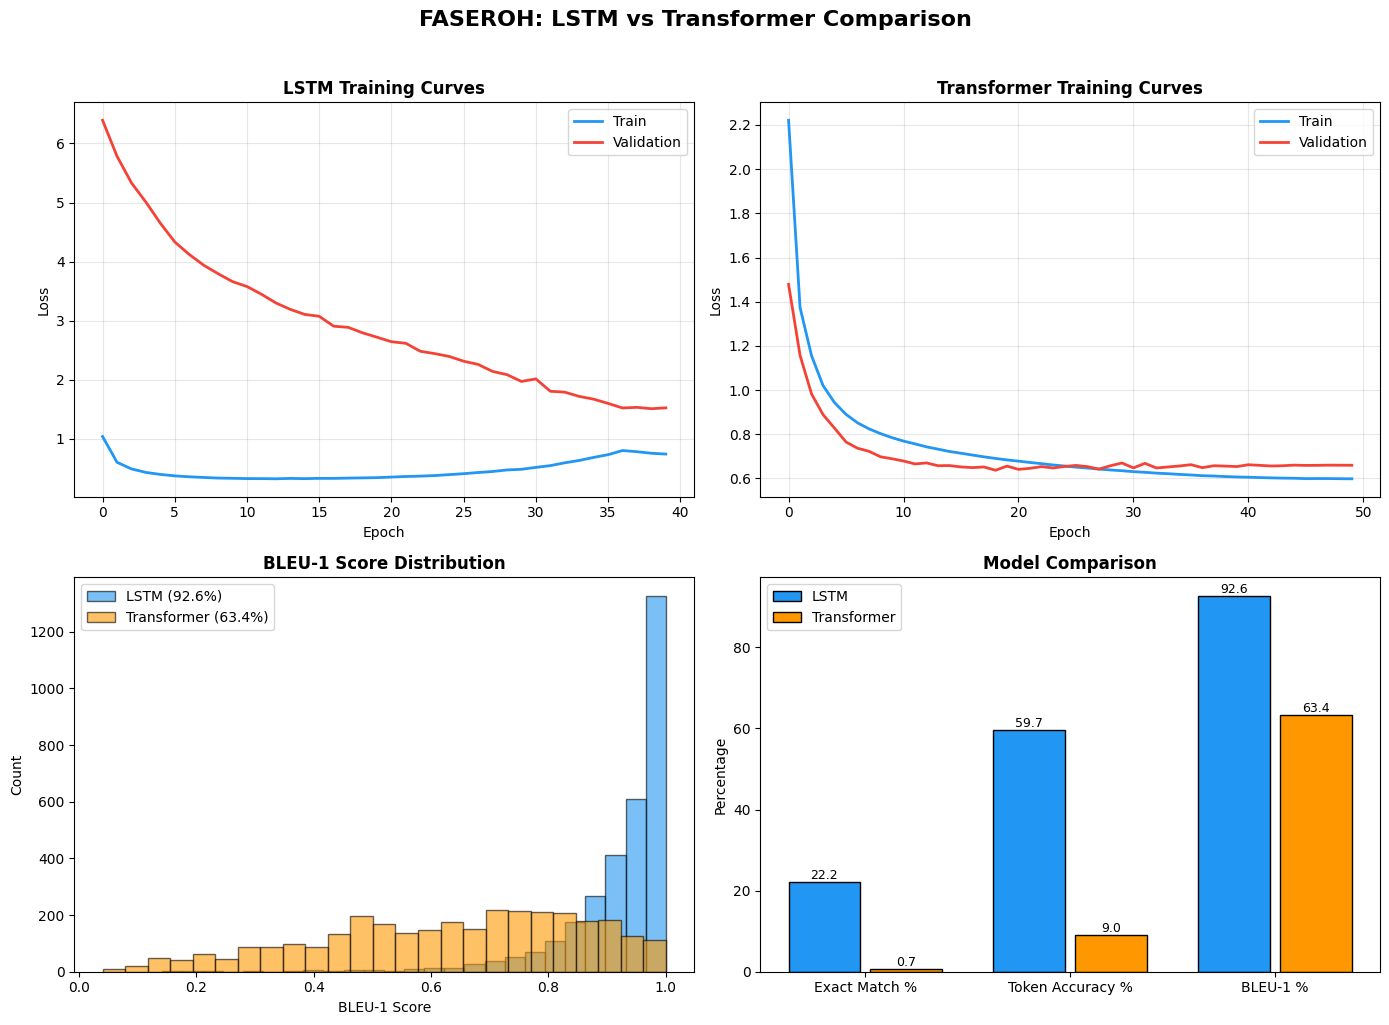


Plot saved: evaluation_plots.png


In [19]:
# ============================================================
# Visualization
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FASEROH: LSTM vs Transformer Comparison', fontsize=16, fontweight='bold', y=1.02)

# 1. LSTM Training Curves
axes[0,0].plot(lstm_history['train'], label='Train', color='#2196F3', linewidth=2)
axes[0,0].plot(lstm_history['val'], label='Validation', color='#F44336', linewidth=2)
axes[0,0].set_title('LSTM Training Curves', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# 2. Transformer Training Curves
axes[0,1].plot(transformer_history['train'], label='Train', color='#2196F3', linewidth=2)
axes[0,1].plot(transformer_history['val'], label='Validation', color='#F44336', linewidth=2)
axes[0,1].set_title('Transformer Training Curves', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# 3. BLEU Score Distribution
axes[1,0].hist(lstm_results['bleu_scores'], bins=25, alpha=0.6, label=f"LSTM ({lstm_results['bleu']:.1f}%)", color='#2196F3', edgecolor='black')
axes[1,0].hist(transformer_results['bleu_scores'], bins=25, alpha=0.6, label=f"Transformer ({transformer_results['bleu']:.1f}%)", color='#FF9800', edgecolor='black')
axes[1,0].set_title('BLEU-1 Score Distribution', fontweight='bold')
axes[1,0].set_xlabel('BLEU-1 Score'); axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 4. Metric Comparison Bars
metrics = ['Exact Match %', 'Token Accuracy %', 'BLEU-1 %']
lstm_vals = [lstm_results['exact_acc'], lstm_results['token_acc'], lstm_results['bleu']]
trans_vals = [transformer_results['exact_acc'], transformer_results['token_acc'], transformer_results['bleu']]
x_pos = np.arange(len(metrics))
bars1 = axes[1,1].bar(x_pos - 0.2, lstm_vals, 0.35, label='LSTM', color='#2196F3', edgecolor='black')
bars2 = axes[1,1].bar(x_pos + 0.2, trans_vals, 0.35, label='Transformer', color='#FF9800', edgecolor='black')
axes[1,1].set_xticks(x_pos); axes[1,1].set_xticklabels(metrics)
axes[1,1].set_title('Model Comparison', fontweight='bold')
axes[1,1].set_ylabel('Percentage'); axes[1,1].legend()
for bar in bars1:
    axes[1,1].annotate(f'{bar.get_height():.1f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1,1].annotate(f'{bar.get_height():.1f}', xy=(bar.get_x()+bar.get_width()/2, bar.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved: evaluation_plots.png")

In [20]:
# Save all results for Notebook 2
pickle.dump({
    'lstm_history': lstm_history,
    'transformer_history': transformer_history,
    'lstm_results': lstm_results,
    'transformer_results': transformer_results,
    'best_lstm_val': best_lstm_val,
    'best_transformer_val': best_transformer_val,
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_INPUT_LEN': MAX_INPUT_LEN,
    'MAX_OUTPUT_LEN': MAX_OUTPUT_LEN,
}, open('notebook1_results.pkl', 'wb'))

print("✅ Notebook 1 complete!")
print("\nSaved files:")
print("  best_lstm.pth          — trained LSTM weights")
print("  best_transformer.pth   — trained Transformer weights")
print("  our_sympy_data.csv     — our SymPy-generated dataset")
print("  evaluation_plots.png   — comparison visualizations")
print("  notebook1_results.pkl  — metrics for Notebook 2")
print("\n→ Continue to Notebook 2 for beam search and teacher forcing decay experiments.")

✅ Notebook 1 complete!

Saved files:
  best_lstm.pth          — trained LSTM weights
  best_transformer.pth   — trained Transformer weights
  our_sympy_data.csv     — our SymPy-generated dataset
  evaluation_plots.png   — comparison visualizations
  notebook1_results.pkl  — metrics for Notebook 2

→ Continue to Notebook 2 for beam search and teacher forcing decay experiments.


In [21]:
import shutil
save_dir = '/content/drive/MyDrive/Colab Notebooks/Gsoc 2026/ML4sci/'

shutil.copy('evaluation_plots.png', save_dir + 'evaluation_plots.png')
shutil.copy('notebook1_results.pkl', save_dir + 'notebook1_results.pkl')
print("✅ All Notebook 1 files saved to Drive!")

✅ All Notebook 1 files saved to Drive!
